In [1]:
# import libraries

# Data Analysis Libraries
import pandas as pd 
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
# Load the dataset
try:
    df = pd.read_csv("day_04_student_performance_prediction_dataset.csv")
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: The dataset file was not found. Please check the file path and try again.")

Dataset loaded successfully.


### Understanding the dataset

In [3]:
df.head()

,Student ID,Student Name,Age,Gender,Course,Attendance,Assignment Score,Midterm Score,Final Score,Result
0,S001,Ali,23,Male,Artificial Intelligence,51,87,70,61,1
1,S002,Fatima,19,Female,Data Science,97,46,46,84,1
2,S003,Bilal,18,Male,Artificial Intelligence,55,53,64,94,1
3,S004,Hina,22,Female,Artificial Intelligence,85,52,88,58,1
4,S005,Hamza,21,Male,Cyber Security,50,88,55,84,1


In [4]:
df.tail()

,Student ID,Student Name,Age,Gender,Course,Attendance,Assignment Score,Midterm Score,Final Score,Result
95,S096,Amna,21,Female,Software Engineering,60,87,95,87,1
96,S097,Farhan,20,Male,Data Science,90,57,97,60,1
97,S098,Komal,20,Female,Software Engineering,54,85,71,60,1
98,S099,Owais,20,Male,Cyber Security,70,97,45,47,0
99,S100,Nimra,19,Female,Data Science,74,84,54,57,1


In [5]:
df.sample(5)

,Student ID,Student Name,Age,Gender,Course,Attendance,Assignment Score,Midterm Score,Final Score,Result
83,S084,Hina,23,Female,Cyber Security,85,48,59,83,1
35,S036,Amna,18,Female,Artificial Intelligence,95,80,42,59,1
61,S062,Fatima,19,Female,Cyber Security,82,71,67,36,0
80,S081,Ali,22,Male,Data Science,73,67,43,72,1
5,S006,Noor,20,Female,Cyber Security,59,53,78,43,0


In [6]:
df.shape

(100, 10)

In [7]:
df.columns

Index(['Student ID', 'Student Name', 'Age', 'Gender', 'Course', 'Attendance',
       'Assignment Score', 'Midterm Score', 'Final Score', 'Result'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Student ID        100 non-null    str  
 1   Student Name      100 non-null    str  
 2   Age               100 non-null    int64
 3   Gender            100 non-null    str  
 4   Course            100 non-null    str  
 5   Attendance        100 non-null    int64
 6   Assignment Score  100 non-null    int64
 7   Midterm Score     100 non-null    int64
 8   Final Score       100 non-null    int64
 9   Result            100 non-null    int64
dtypes: int64(6), str(4)
memory usage: 7.9 KB


In [9]:
df.describe()

,Age,Attendance,Assignment Score,Midterm Score,Final Score,Result
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,21.190000,73.580000,68.740000,66.890000,64.490000,0.730000
std,1.993398,15.738507,17.134418,19.217992,19.804854,0.446196
min,18.000000,50.000000,40.000000,35.000000,30.000000,0.000000
25%,20.000000,58.750000,55.000000,50.750000,46.250000,0.000000
50%,21.000000,72.000000,67.000000,64.000000,61.000000,1.000000
75%,23.000000,88.250000,82.500000,86.000000,81.000000,1.000000
max,24.000000,100.000000,99.000000,100.000000,100.000000,1.000000


In [10]:
# check missing values
df.isnull().sum()

Student ID          0
Student Name        0
Age                 0
Gender              0
Course              0
Attendance          0
Assignment Score    0
Midterm Score       0
Final Score         0
Result              0
dtype: int64

In [11]:
# check duplicates values
df.duplicated()

0     False
1     False
2     False
3     False
4     False
      ...  
95    False
96    False
97    False
98    False
99    False
Length: 100, dtype: bool

In [12]:
# Check data types
df.dtypes

Student ID            str
Student Name          str
Age                 int64
Gender                str
Course                str
Attendance          int64
Assignment Score    int64
Midterm Score       int64
Final Score         int64
Result              int64
dtype: object

In [13]:
# Rename the columns
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)
df.columns

Index(['student_id', 'student_name', 'age', 'gender', 'course', 'attendance',
       'assignment_score', 'midterm_score', 'final_score', 'result'],
      dtype='str')

In [14]:
# Exploratory Data Analysis (EDA)
df["course"].value_counts()

course
Cyber Security             28
Artificial Intelligence    25
Data Science               25
Software Engineering       22
Name: count, dtype: int64

In [15]:
df["attendance"].value_counts()

attendance
58     6
93     5
55     4
59     4
60     4
82     4
100    4
85     3
50     3
56     3
90     3
63     3
57     3
87     3
72     3
51     2
97     2
52     2
94     2
70     2
74     2
69     2
95     2
54     2
80     2
66     2
73     2
89     2
67     2
92     2
79     2
96     1
99     1
88     1
83     1
71     1
76     1
84     1
61     1
75     1
77     1
65     1
64     1
98     1
Name: count, dtype: int64

In [16]:
df["gender"].value_counts()

gender
Male      50
Female    50
Name: count, dtype: int64

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   student_id        100 non-null    str  
 1   student_name      100 non-null    str  
 2   age               100 non-null    int64
 3   gender            100 non-null    str  
 4   course            100 non-null    str  
 5   attendance        100 non-null    int64
 6   assignment_score  100 non-null    int64
 7   midterm_score     100 non-null    int64
 8   final_score       100 non-null    int64
 9   result            100 non-null    int64
dtypes: int64(6), str(4)
memory usage: 7.9 KB


In [18]:
# separating numerical features
numerical_features = [
    "age",
    "attendance",
    "assignment_score",
    "midterm_score",
    "final_score"
]

In [19]:
# separating categorical features
categorical_features = [
    "gender",
    "course"
]

### Creating pipeline separtely for each numerical and categorical columns

In [20]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [21]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

#### Combine Both Pipeline

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

At this point:

Numerical columns → Missing values filled → Standardized

Categorical columns → Missing values filled → One-Hot Encoded

In [23]:
df.columns

Index(['student_id', 'student_name', 'age', 'gender', 'course', 'attendance',
       'assignment_score', 'midterm_score', 'final_score', 'result'],
      dtype='str')

In [24]:
# Separate Features and Target

X = df.drop(columns=["student_id","student_name","result"])
y = df["result"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### Build Complete Pipeline

In [26]:
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression())
    ]
)

In [27]:
# train the model 
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['age','gender','course',...,'assignment_score','midterm_score', 'final_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrou

In [28]:
y_pred = model_pipeline.predict(X_test)

In [29]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 100.00%


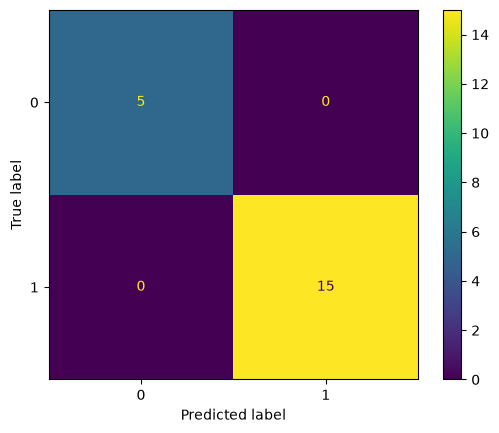

In [30]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()

plt.show()

In [31]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00        15

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



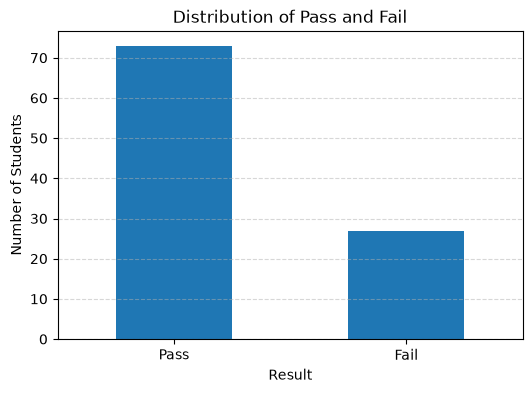

In [32]:
# Distribution of Pass vs Fail
 
plt.figure(figsize=(6, 4))

df["result"].value_counts().plot(kind="bar")

plt.title("Distribution of Pass and Fail")
plt.xlabel("Result")
plt.ylabel("Number of Students")

plt.xticks([0, 1], ["Pass", "Fail"], rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

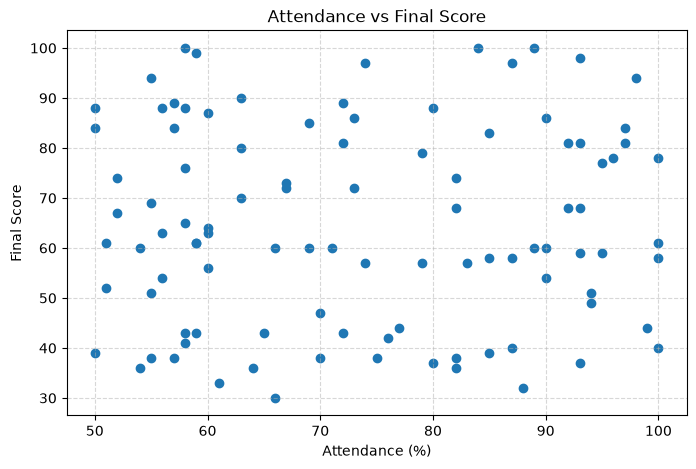

In [33]:
# Attendance vs Final Score 

plt.figure(figsize=(8, 5))

plt.scatter(
    df["attendance"],
    df["final_score"]
)

plt.title("Attendance vs Final Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Final Score")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

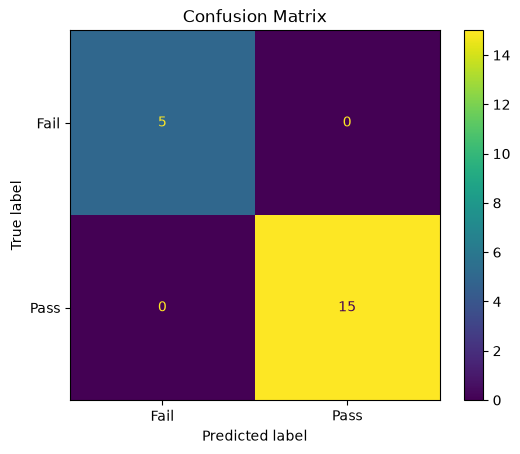

In [34]:
cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
)

display.plot()

plt.title("Confusion Matrix")

plt.show()

### Improve model perfomance using GridSearchCV

In [38]:
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from sklearn.tree import DecisionTreeClassifier

In [39]:
numeric_pipeline 

categorical_pipeline

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [ ]:
# Baseline Model

baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

baseline_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['age','gender','course',...,'assignment_score','midterm_score', 'final_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrou

In [43]:
# Hyperparameter Tuning

tuned_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

In [47]:
# Define Parameter Grid

param_grid = {
    "classifier__criterion": ['gini', "entropy"],
    "classifier__max_depth": [3, 5, 7, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

In [48]:
# GridSearchCV 

grid_search = GridSearchCV(
    estimator=tuned_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

##### Train it

In [49]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__criterion': ['gini', 'entropy'], 'classifier__max_depth': [3, 5, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versio

In [50]:
# select best parameter

print(grid_search.best_params_)

{'classifier__criterion': 'gini', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}


In [51]:
# Best Model 

best_model = grid_search.best_estimator_

In [52]:
y_pred = best_model.predict(X_test)

In [53]:
def evaluate_model(name, y_true, y_pred):

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_pred)
    }

In [54]:
baseline_results = evaluate_model(
    "Decision Tree",
    y_test,
    baseline_pipeline.predict(X_test)
)

tuned_results = evaluate_model(
    "GridSearchCV Decision Tree",
    y_test,
    best_model.predict(X_test)
)

In [55]:
comparison = pd.DataFrame([
    baseline_results,
    tuned_results
])

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,1.0,1.0,1.0,1.0,1.0
1,GridSearchCV Decision Tree,1.0,1.0,1.0,1.0,1.0


In [61]:
print(comparison)

                        Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0               Decision Tree       1.0        1.0     1.0       1.0      1.0
1  GridSearchCV Decision Tree       1.0        1.0     1.0       1.0      1.0


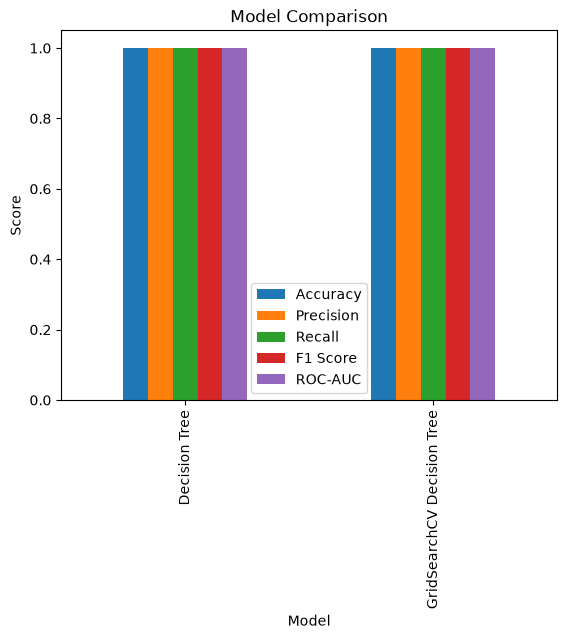

In [56]:
comparison.set_index("Model").plot(kind="bar")

plt.title("Model Comparison")

plt.ylabel("Score")

plt.show()

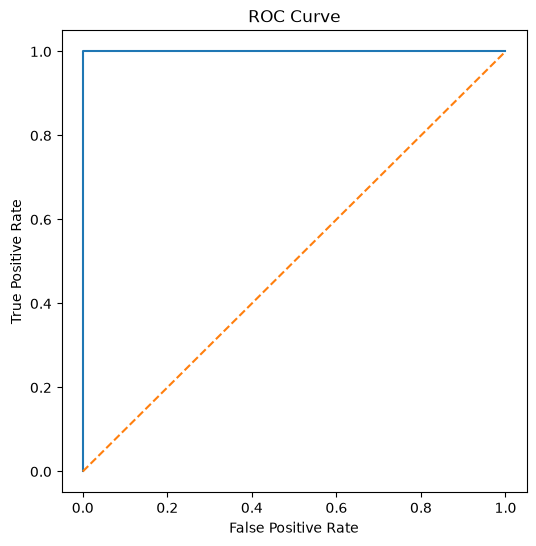

In [57]:
probabilities = best_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    probabilities
)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [58]:
roc_auc = roc_auc_score(
    y_test,
    probabilities
)

print(roc_auc)

1.0


In [60]:
df["average_score"] = (
    df["assignment_score"] +
    df["midterm_score"] +
    df["final_score"]
) / 3